# Mall Customer Segmentation — K-Means Clustering

Find the optimal number of clusters using the elbow method and silhouette score, then characterise each segment.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from utils import find_optimal_k, fit_kmeans, cluster_summary, plot_elbow, plot_silhouette
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('data/mall_customers_cleaned.csv')
X_scaled = pd.read_csv('data/mall_customers_scaled.csv').values
feature_cols = ['Age', 'Income', 'SpendingScore', 'Gender_Male']
print('Shape:', df.shape, 'X_scaled:', X_scaled.shape)
df.head()

Shape: (200, 4) X_scaled: (200, 4)


,Age,Income,SpendingScore,Gender_Male
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


## 2. Choose K — Elbow + Silhouette

In [3]:
metrics_df = find_optimal_k(X_scaled, k_range=range(2, 11))
metrics_df.round(4)

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,588.8027,0.2518,1.6138,71.0205
1,3,476.7876,0.2595,1.3574,66.7728
2,4,388.7179,0.2984,1.2807,69.1258
3,5,331.3099,0.3041,1.1672,68.9646
4,6,276.4118,0.3311,1.0177,73.4962
5,7,236.2049,0.3574,0.9802,76.7783
6,8,199.7505,0.3880,0.9445,82.4228
7,9,174.2355,0.4031,0.8750,85.7468
8,10,152.0298,0.4208,0.8331,89.9782


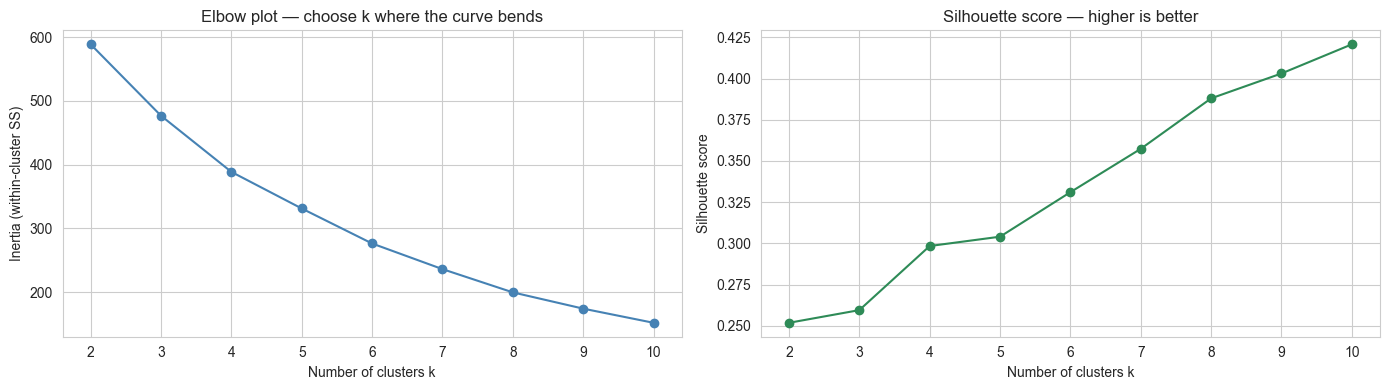

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_elbow(metrics_df, ax=axes[0])
plot_silhouette(metrics_df, ax=axes[1])
plt.tight_layout(); plt.show()

In [5]:
best_k_silhouette = int(metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k'])
print('Best k by silhouette:', best_k_silhouette)
best_k = best_k_silhouette  # use silhouette winner

Best k by silhouette: 10


## 3. Fit K-Means with the Chosen K

In [6]:
km, labels = fit_kmeans(X_scaled, best_k)
df_labelled = df.copy(); df_labelled['cluster'] = labels
print('Cluster sizes:'); print(df_labelled['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    26
1    24
2    14
3    21
4    26
5    19
6    25
7    18
8    13
9    14
Name: count, dtype: int64


## 4. Visualize Clusters — Income vs SpendingScore

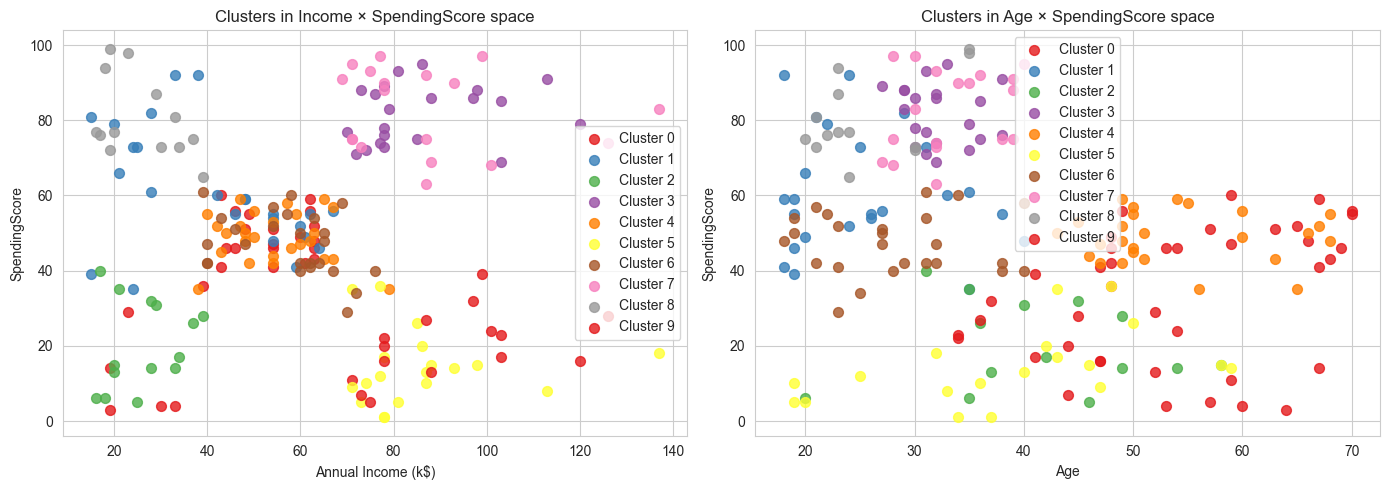

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('Set1', best_k)
for c in range(best_k):
    sub = df_labelled[df_labelled['cluster'] == c]
    axes[0].scatter(sub['Income'], sub['SpendingScore'], color=palette[c], label=f'Cluster {c}', alpha=0.8, s=50)
axes[0].set_xlabel('Annual Income (k$)'); axes[0].set_ylabel('SpendingScore')
axes[0].set_title('Clusters in Income × SpendingScore space'); axes[0].legend()
for c in range(best_k):
    sub = df_labelled[df_labelled['cluster'] == c]
    axes[1].scatter(sub['Age'], sub['SpendingScore'], color=palette[c], label=f'Cluster {c}', alpha=0.8, s=50)
axes[1].set_xlabel('Age'); axes[1].set_ylabel('SpendingScore')
axes[1].set_title('Clusters in Age × SpendingScore space'); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. PCA — 2D View of Clusters

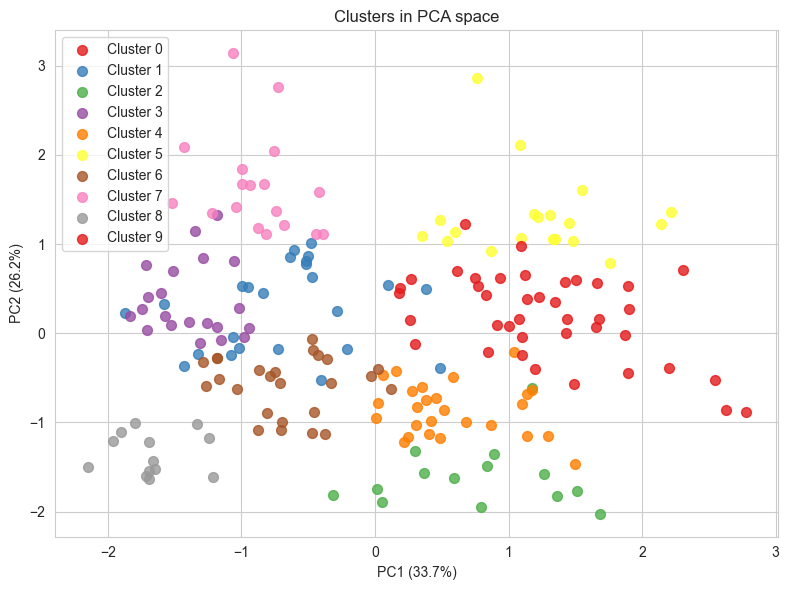

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))
for c in range(best_k):
    mask = labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[c], label=f'Cluster {c}', alpha=0.8, s=50)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Clusters in PCA space'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Cluster Profile Summary

In [9]:
summary = cluster_summary(df, labels)
summary

,Age,Income,SpendingScore,Gender_Male,Count
cluster,,,,,
0,58.85,48.69,39.85,1.00,26
1,25.25,41.25,60.92,1.00,24
2,41.21,26.07,20.14,0.07,14
3,32.19,86.05,81.67,0.00,21
4,54.15,54.23,48.96,0.00,26
5,38.47,85.89,14.21,1.00,19
6,27.96,57.36,47.12,0.00,25
7,33.28,87.11,82.67,1.00,18
8,25.46,25.69,80.54,0.00,13


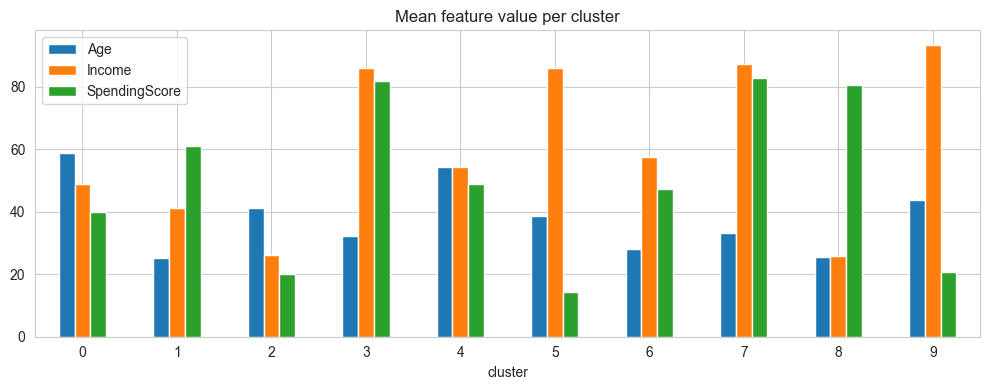

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
summary.drop(columns=['Count'])[['Age', 'Income', 'SpendingScore']].plot(kind='bar', ax=ax)
ax.set_title('Mean feature value per cluster')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 7. Compare to Hierarchical Clustering

In [11]:
agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(X_scaled)
print('Silhouette — KMeans     :', round(silhouette_score(X_scaled, labels), 4))
print('Silhouette — Hierarchical:', round(silhouette_score(X_scaled, agg_labels), 4))
ct = pd.crosstab(labels, agg_labels)
print('\nKMeans (rows) vs Hierarchical (cols) cluster overlap:')
ct

Silhouette — KMeans     : 0.4208
Silhouette — Hierarchical: 0.4176

KMeans (rows) vs Hierarchical (cols) cluster overlap:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,25,1,0,0,0,0,0,0,0,0
1,2,0,22,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,13
3,0,0,0,0,0,0,21,0,0,0
4,0,0,0,25,0,0,0,1,0,0
5,2,17,0,0,0,0,0,0,0,0
6,0,0,0,0,25,0,0,0,0,0
7,0,0,0,0,0,18,0,0,0,0
8,0,0,0,0,0,0,0,0,13,0


## 8. Cluster Naming & Marketing Personas

In [12]:
personas = []
for c in range(best_k):
    mean_inc = summary.loc[c, 'Income']
    mean_score = summary.loc[c, 'SpendingScore']
    mean_age = summary.loc[c, 'Age']
    if mean_inc > 60 and mean_score > 60: name = 'Target — high income, high spend'
    elif mean_inc > 60 and mean_score < 40: name = 'Cautious — high income, low spend'
    elif mean_inc < 40 and mean_score > 60: name = 'Impulsive — low income, high spend'
    elif mean_inc < 40 and mean_score < 40: name = 'Frugal — low income, low spend'
    else: name = 'Average shopper'
    personas.append({'cluster': c, 'persona': name,
                     'avg_age': mean_age, 'avg_income': mean_inc,
                     'avg_spending': mean_score, 'count': summary.loc[c, 'Count']})
personas_df = pd.DataFrame(personas)
personas_df

,cluster,persona,avg_age,avg_income,avg_spending,count
0,0,Average shopper,58.85,48.69,39.85,26
1,1,Average shopper,25.25,41.25,60.92,24
2,2,"Frugal — low income, low spend",41.21,26.07,20.14,14
3,3,"Target — high income, high spend",32.19,86.05,81.67,21
4,4,Average shopper,54.15,54.23,48.96,26
5,5,"Cautious — high income, low spend",38.47,85.89,14.21,19
6,6,Average shopper,27.96,57.36,47.12,25
7,7,"Target — high income, high spend",33.28,87.11,82.67,18
8,8,"Impulsive — low income, high spend",25.46,25.69,80.54,13
9,9,"Cautious — high income, low spend",43.79,93.29,20.64,14


### Key Takeaways

- K-Means with k chosen by silhouette identifies clear, interpretable customer segments.
- Income × SpendingScore is the dominant axis; age and gender are secondary.
- The **high-income / high-spend** segment is the prime marketing target.
- The **high-income / low-spend** segment may be persuadable with the right offer — they have the means but choose not to.
- Hierarchical clustering produces similar segments, which raises confidence that the partition is real.

### Next Steps

- Try DBSCAN to find density-based outliers (atypical shoppers).
- Bring in transaction-level data for richer segmentation.
- Validate segments against actual marketing-campaign response data.